# 11 — Education & Soft Skills

Education level requirements and soft skill demand across the German IT job market. Covers how education expectations vary by job family and seniority, the relationship between education and salary, and which soft skill categories dominate different roles.

In [1]:
from analysis.utils import notebook_init
from analysis.filters import exclude_future_dates, exclude_other_family, salary_df, explode_json_col
from analysis.compute import soft_skill_category_by_family
from analysis import charts as _charts
from analysis.charts import horizontal_bar, heatmap, stacked_bar, box_plot

import pandas as pd
import numpy as np
from shared.json_utils import parse_json_list

df_raw = notebook_init()
df = exclude_future_dates(df_raw)
print(f"After excluding future-dated rows: {len(df):,} rows")

Loaded 18,949 rows × 25 columns
After excluding future-dated rows: 18,899 rows


## Data Quality: Education & Soft Skills Coverage

In [2]:
edu_specified = df["education_level"].notna().sum()
has_soft_skills = df["soft_skill_categories"].apply(lambda v: bool(parse_json_list(v))).sum()
sdf = salary_df(df)
sdf_edu = sdf[sdf["education_level"].notna()]

print(f"Total postings: {len(df):,}")
print()
print("Education level:")
print(f"  Specified:   {edu_specified:,} ({edu_specified/len(df)*100:.1f}%)")
print(f"  Unspecified: {len(df) - edu_specified:,} ({(len(df) - edu_specified)/len(df)*100:.1f}%)")
print()
print("Soft skills:")
print(f"  With categories: {has_soft_skills:,} ({has_soft_skills/len(df)*100:.1f}%)")
print(f"  Without:         {len(df) - has_soft_skills:,} ({(len(df) - has_soft_skills)/len(df)*100:.1f}%)")
print()
print("Education × Salary intersection:")
print(f"  Rows with both education + salary: {len(sdf_edu):,}")

Total postings: 18,899

Education level:
  Specified:   11,213 (59.3%)
  Unspecified: 7,686 (40.7%)

Soft skills:
  With categories: 16,645 (88.1%)
  Without:         2,254 (11.9%)

Education × Salary intersection:
  Rows with both education + salary: 203


**Takeaway:** Education level is specified in the majority of postings, making it a reliable signal. Soft skill data coverage is also strong. However, the intersection of education and salary data is very small, so the education–salary analysis should be interpreted as directional rather than statistically robust.

## Education Level Distribution

Education level specified: 11,213 / 18,899 (59.3%)


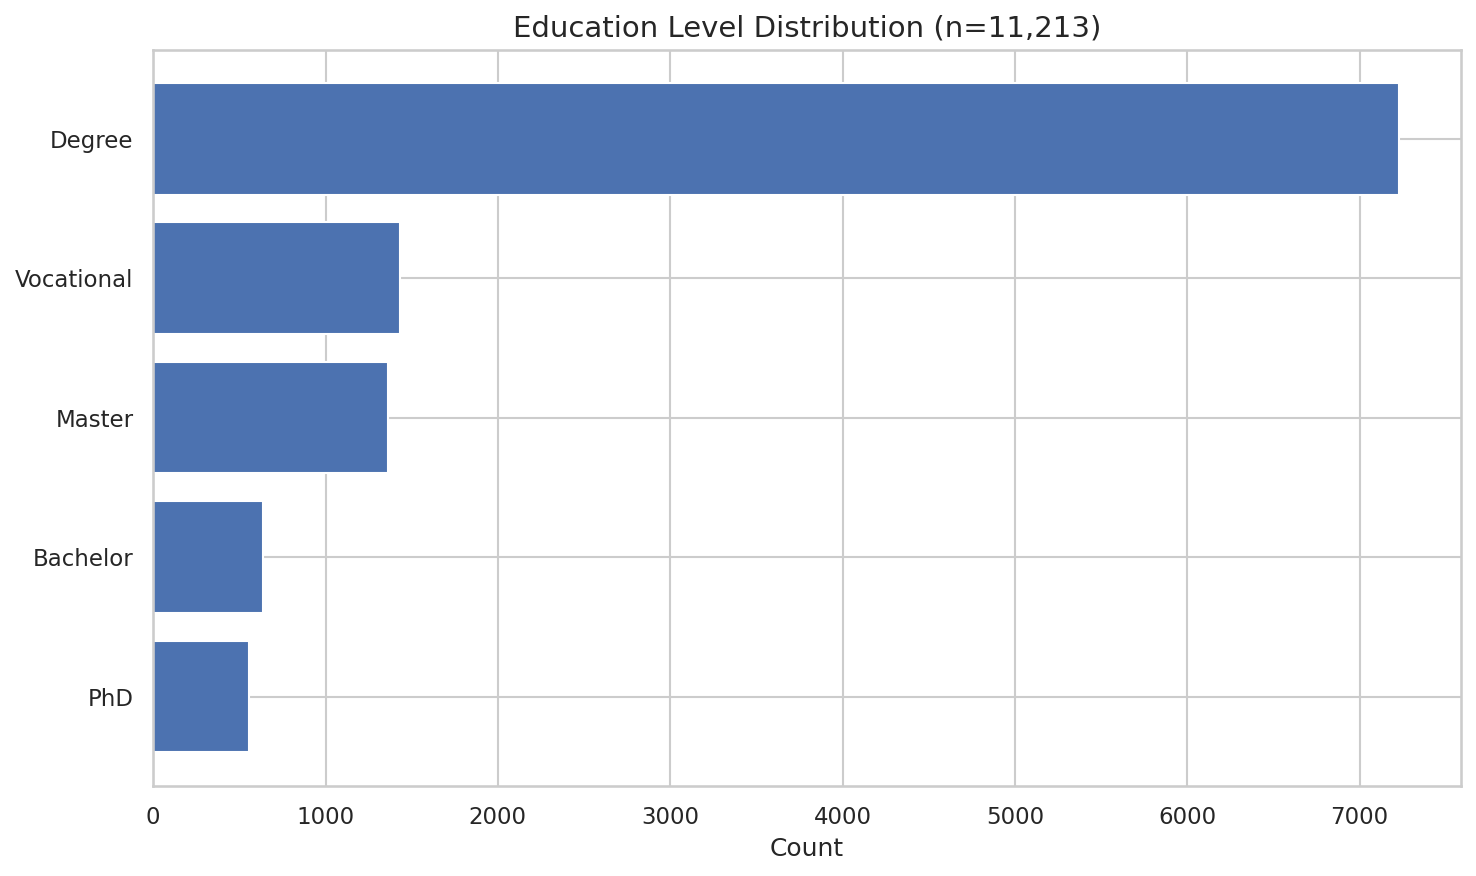

In [3]:
edu_counts = df["education_level"].value_counts()
not_specified = df["education_level"].isna().sum()
n_specified = len(df) - not_specified
print(f"Education level specified: {n_specified:,} / {len(df):,} ({n_specified/len(df)*100:.1f}%)")

horizontal_bar(
    df["education_level"].dropna(),
    f"Education Level Distribution (n={n_specified:,})",
    save_as="11_education_distribution.png",
)

**Takeaway:** "Degree" (unspecified level) is the most common education requirement, reflecting that many German IT postings require a university education without specifying Bachelor vs Master. Bachelor and Master are roughly equally common when specified, while PhD requirements are rare and concentrated in research-oriented roles.

## Education by Job Family (top 10, excluding Other)

Postings per family:
  SAP Consultant: n=1,858
  System Administrator: n=1,767
  Software Developer: n=1,606
  Fullstack Developer: n=1,529
  Solution Architect: n=1,140
  Backend Developer: n=795
  Data Engineer: n=776
  Cloud Engineer: n=727
  DevOps Engineer: n=725
  IT Security Engineer: n=542



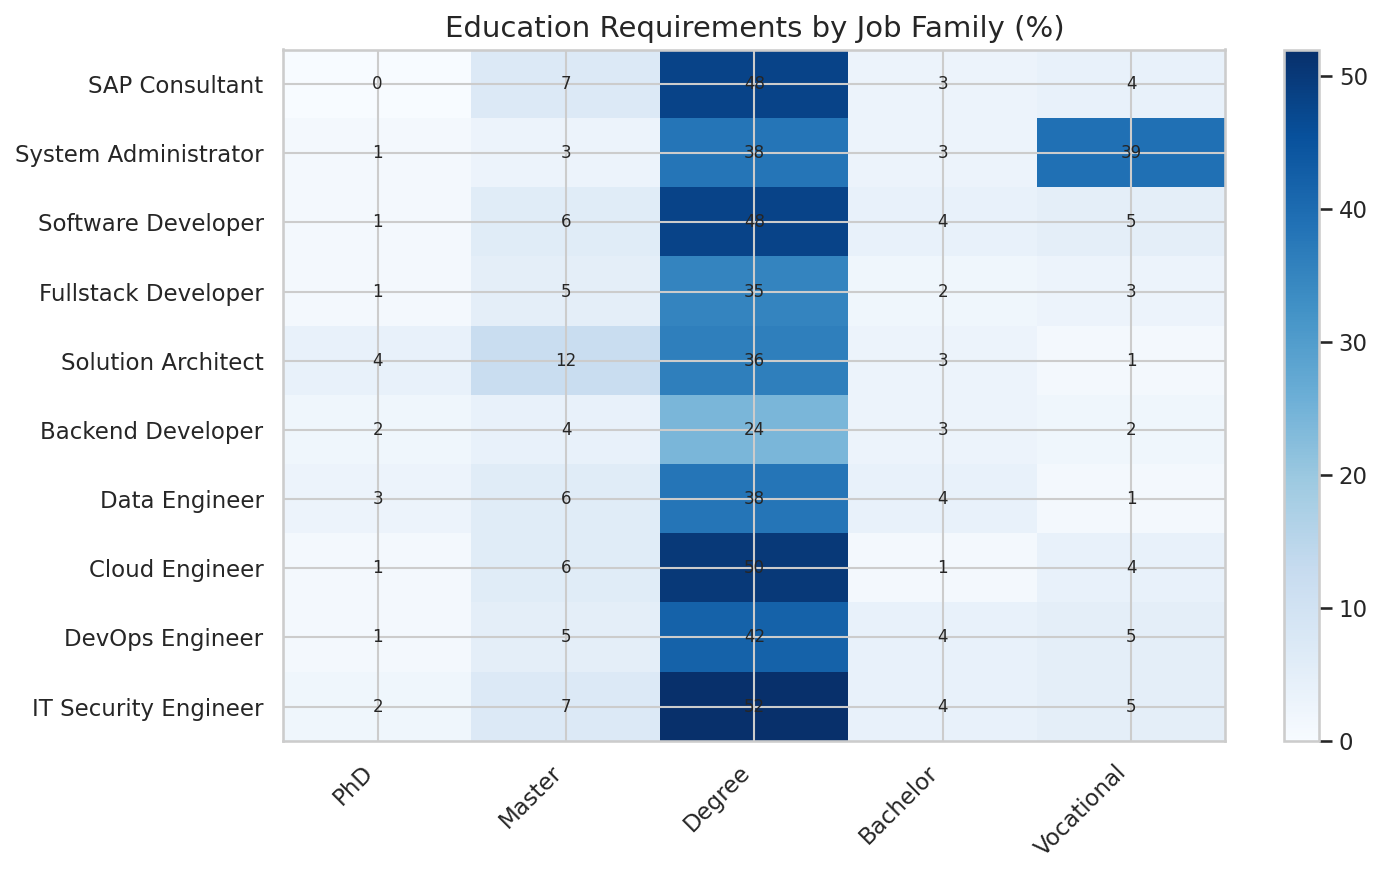


Education distribution (%)


,PhD,Master,Degree,Bachelor,Vocational
job_family,,,,,
SAP Consultant,0.5,7.3,47.6,2.7,4.0
System Administrator,0.5,3.0,38.0,3.1,38.8
Software Developer,1.2,5.7,47.8,4.4,5.0
Fullstack Developer,0.6,5.2,34.7,1.5,3.0
Solution Architect,4.1,12.0,36.2,2.7,0.5
Backend Developer,1.6,3.8,24.4,2.8,2.3
Data Engineer,3.2,6.3,37.8,4.1,0.8
Cloud Engineer,0.6,6.3,49.7,0.7,3.7
DevOps Engineer,0.8,4.6,41.7,3.7,5.4


In [4]:
df_fam = exclude_other_family(df)
edu_levels = ["PhD", "Master", "Degree", "Bachelor", "Vocational"]
top_families = df_fam["job_family"].value_counts().head(10).index

edu_data = []
for family in top_families:
    fam_df = df_fam[df_fam["job_family"] == family]
    total = max(1, len(fam_df))
    row = {"job_family": family}
    for level in edu_levels:
        row[level] = (fam_df["education_level"] == level).sum() / total * 100
    edu_data.append(row)

edu_df = pd.DataFrame(edu_data).set_index("job_family")

# Print family sizes for context
print("Postings per family:")
for fam in top_families:
    n = len(df_fam[df_fam["job_family"] == fam])
    print(f"  {fam}: n={n:,}")
print()

heatmap(
    edu_df[edu_levels].round(0),
    "Education Requirements by Job Family (%)",
    figsize=(10, 6),
    save_as="11_education_by_family.png",
)

print("\nEducation distribution (%)")
edu_df.round(1)

**Takeaway:** Data Science and research-adjacent roles show the highest rates of Master/PhD requirements, while development roles more commonly accept a Bachelor or general degree. Vocational training (Ausbildung) is most prevalent in IT support and system administration roles, reflecting Germany's strong dual education system.

## Education × Salary

> **Caution:** Only ~2% of postings have salary data. Cross-filtering with education further reduces the sample.

Rows with both salary and education data: 203

Sample sizes per education level:
  Degree: n=132
  Vocational: n=35
  Master: n=19
  Bachelor: n=15
  PhD: n=2


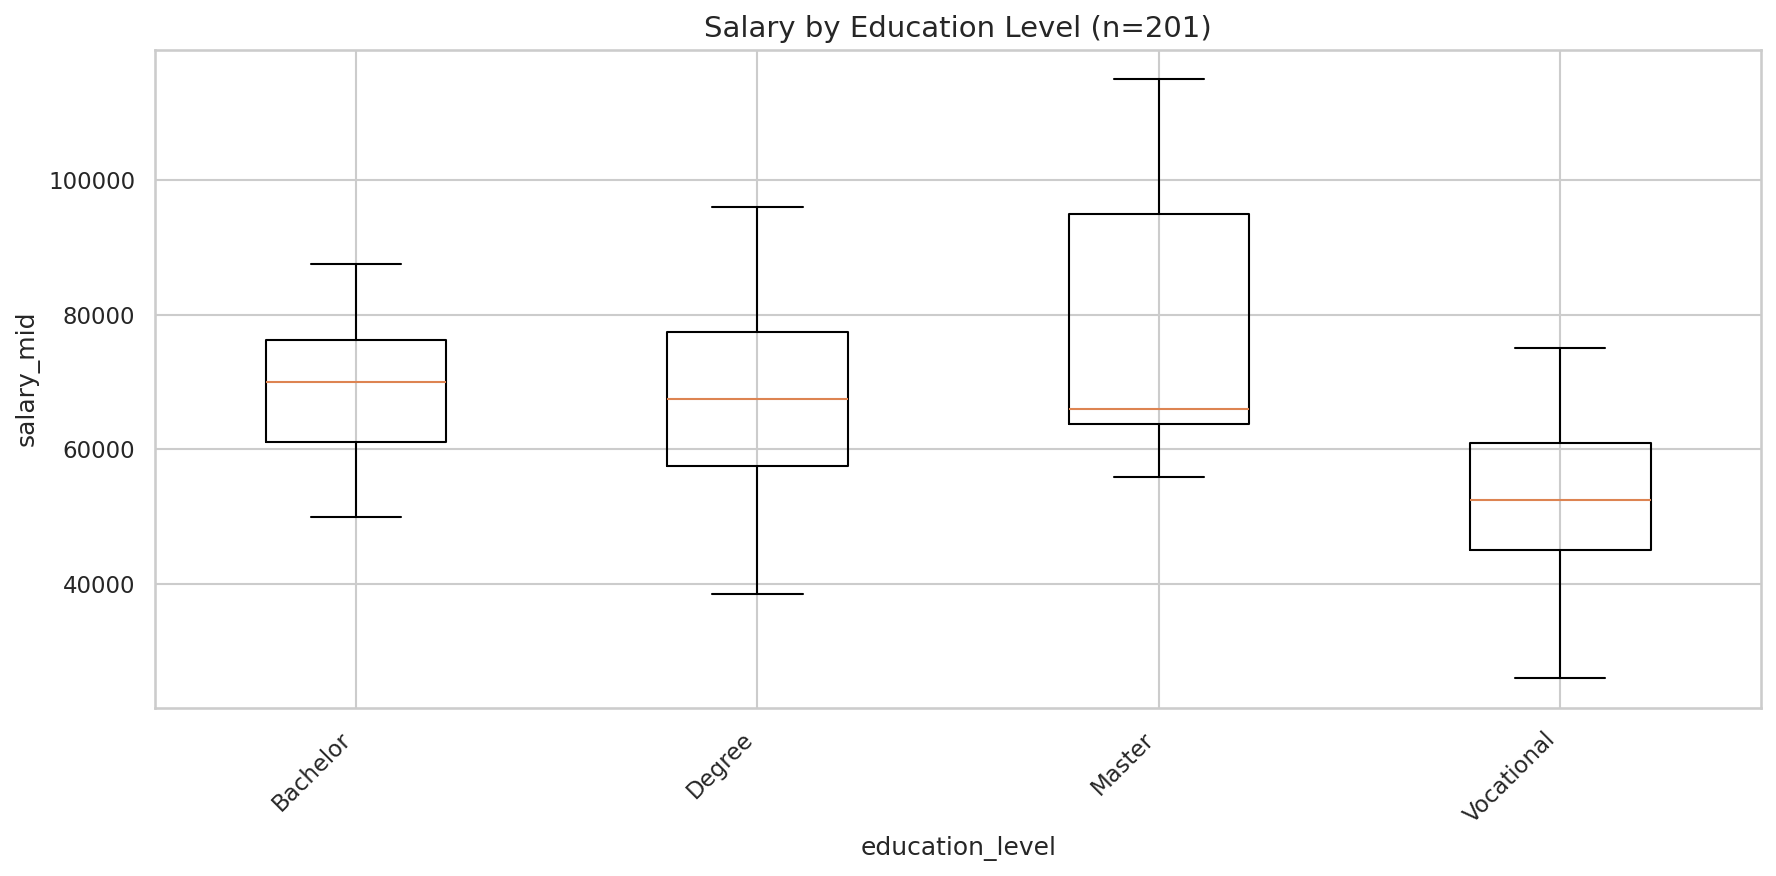

In [5]:
sdf = salary_df(df)
sdf_edu = sdf[sdf["education_level"].notna()].copy()
print(f"Rows with both salary and education data: {len(sdf_edu):,}")

# Show counts per education level
edu_salary_counts = sdf_edu["education_level"].value_counts()
print("\nSample sizes per education level:")
for level, count in edu_salary_counts.items():
    print(f"  {level}: n={count}")

# Only show education levels with enough data points
valid_levels = edu_salary_counts[edu_salary_counts >= 5].index.tolist()

if len(valid_levels) >= 2:
    # Order consistently
    level_order = ["Vocational", "Bachelor", "Degree", "Master", "PhD"]
    valid_ordered = [lvl for lvl in level_order if lvl in valid_levels]
    sdf_plot = sdf_edu[sdf_edu["education_level"].isin(valid_ordered)].copy()
    # Force ordering via categorical
    sdf_plot["education_level"] = pd.Categorical(
        sdf_plot["education_level"], categories=valid_ordered, ordered=True
    )

    box_plot(
        sdf_plot, "education_level", "salary_mid",
        f"Salary by Education Level (n={len(sdf_plot):,})",
        save_as="11_salary_by_education.png",
    )
else:
    print(f"\nOnly {len(valid_levels)} education level(s) have >= 5 salary rows — skipping box plot.")
    print("Counts per level:")
    print(edu_salary_counts)

**Takeaway:** Due to the very small salary sample, differences between education levels should be treated as suggestive. The general pattern — higher education correlating with higher median salary — is expected, but confounding factors (seniority, role type, company size) are not controlled for here. The main actionable insight is that salary data is too sparse for reliable education–salary conclusions.

## Education by Seniority

Sample sizes per seniority level:
  Junior: n=736
  Mid: n=13,050
  Senior: n=4,162
  Lead: n=884



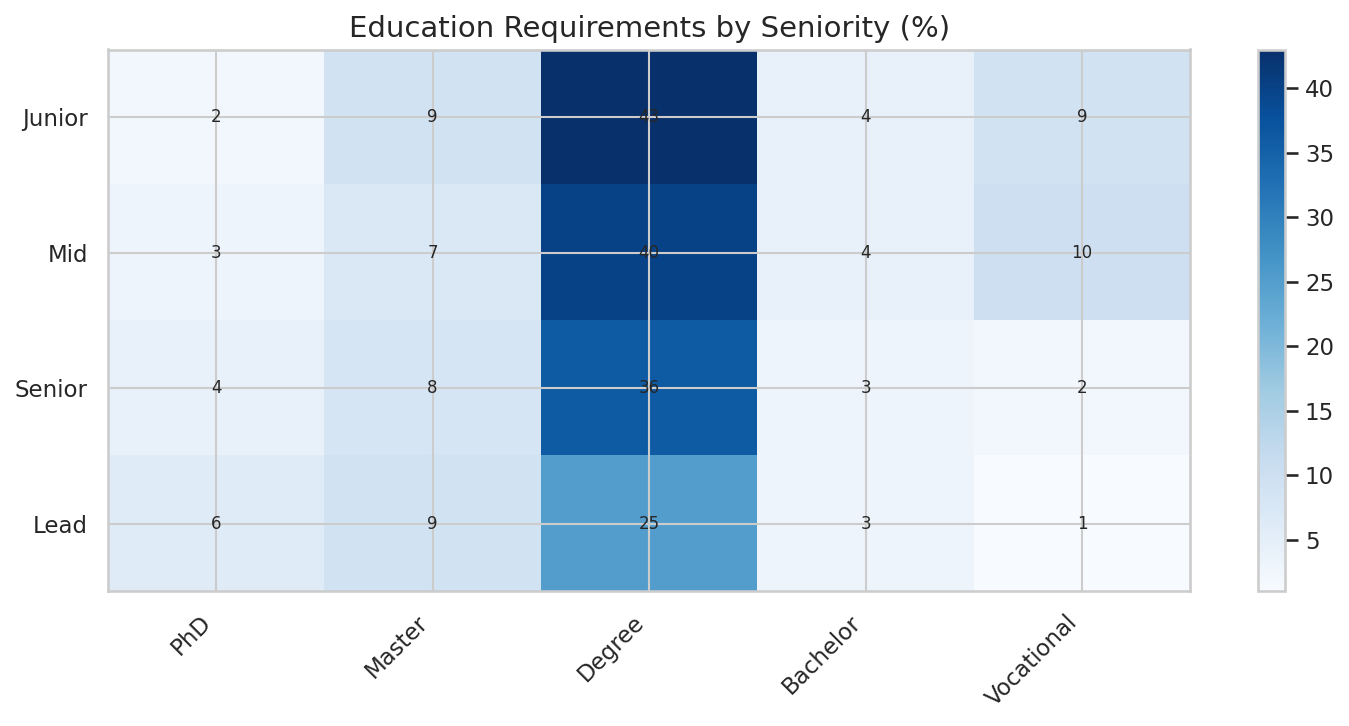

,PhD,Master,Degree,Bachelor,Vocational
seniority,,,,,
Junior,2.0,9.0,42.9,4.1,9.4
Mid,2.5,6.7,39.7,3.5,9.6
Senior,3.5,8.0,36.1,2.8,2.3
Lead,6.3,9.3,25.3,2.9,0.9


In [6]:
levels = ["Junior", "Mid", "Senior", "Lead"]
df_sen = df.copy()
df_sen["_level"] = df_sen["seniority_from_title"].fillna("Mid")
df_sen = df_sen[df_sen["_level"].isin(levels)]

edu_sen_data = []
for level in levels:
    level_df = df_sen[df_sen["_level"] == level]
    total = max(1, len(level_df))
    row = {"seniority": level}
    for edu in edu_levels:
        row[edu] = (level_df["education_level"] == edu).sum() / total * 100
    edu_sen_data.append(row)

edu_sen_df = pd.DataFrame(edu_sen_data).set_index("seniority")

# Show sample sizes
print("Sample sizes per seniority level:")
for level in levels:
    n = len(df_sen[df_sen["_level"] == level])
    print(f"  {level}: n={n:,}")
print()

heatmap(
    edu_sen_df[edu_levels].round(0),
    "Education Requirements by Seniority (%)",
    figsize=(10, 5),
    save_as="11_education_by_seniority.png",
)

edu_sen_df.round(1)

**Takeaway:** Education requirements are relatively consistent across seniority levels, suggesting that German IT employers set a baseline education expectation at entry and do not significantly escalate it for senior hires. Experience and demonstrated skills likely matter more than additional degrees for career progression.

## Soft Skill Categories by Job Family

Postings per family (for heatmap):
  SAP Consultant: n=1,858
  System Administrator: n=1,767
  Software Developer: n=1,606
  Fullstack Developer: n=1,529
  Solution Architect: n=1,140
  Backend Developer: n=795
  Data Engineer: n=776
  Cloud Engineer: n=727
  DevOps Engineer: n=725
  IT Security Engineer: n=542



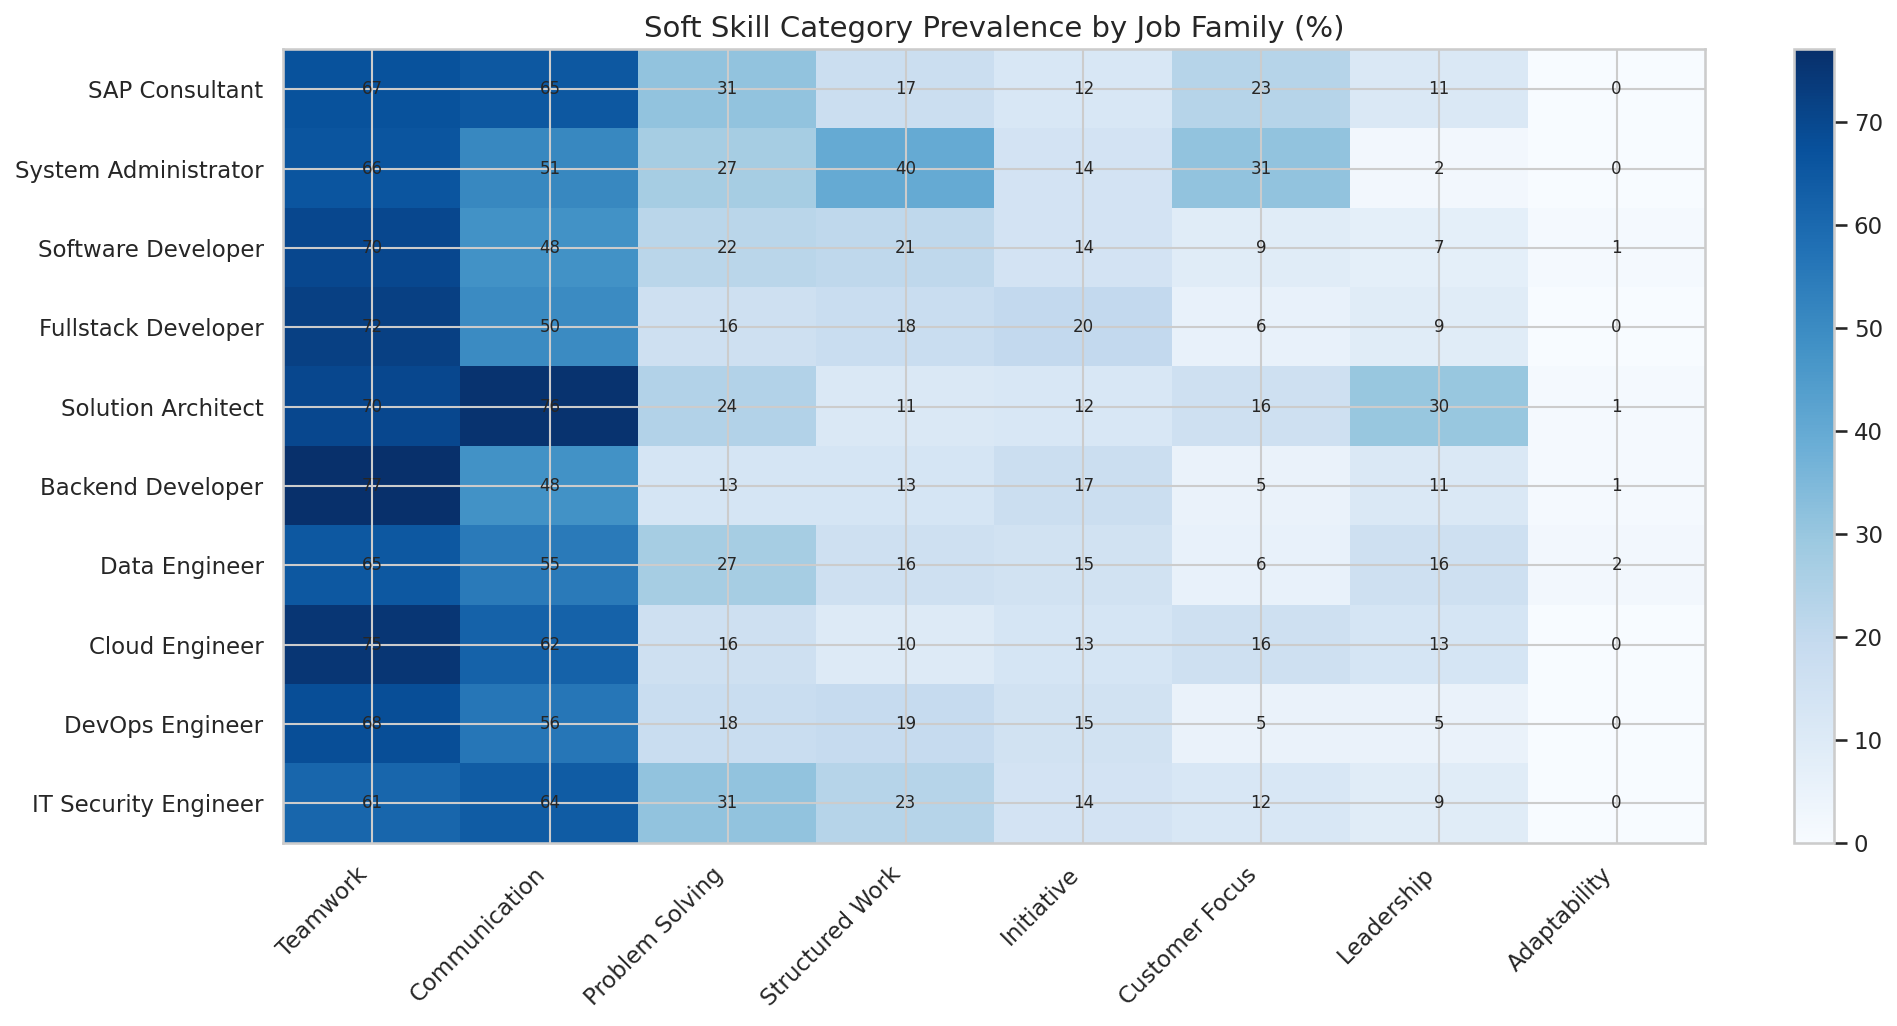

In [7]:
df_fam = exclude_other_family(df)
ss_heatmap = soft_skill_category_by_family(df_fam, top_n_families=10)

# Sort columns by overall prevalence
col_order = ss_heatmap.mean().sort_values(ascending=False).index
ss_heatmap = ss_heatmap[col_order]

# Show family sizes
print("Postings per family (for heatmap):")
fam_counts = df_fam["job_family"].value_counts()
for fam in ss_heatmap.index:
    print(f"  {fam}: n={fam_counts.get(fam, 0):,}")
print()

heatmap(
    ss_heatmap.round(0),
    "Soft Skill Category Prevalence by Job Family (%)",
    figsize=(14, 7),
    fmt=".0f",
    save_as="11_soft_skills_by_family.png",
)

**Takeaway:** Communication and teamwork are universally valued across all IT job families. However, some differentiation exists: leadership skills are more emphasised in management-oriented roles, while analytical thinking features more in data-centric families. Creative skills are most prominent in UX/UI and frontend roles, as expected.

## Top Soft Skills Overall

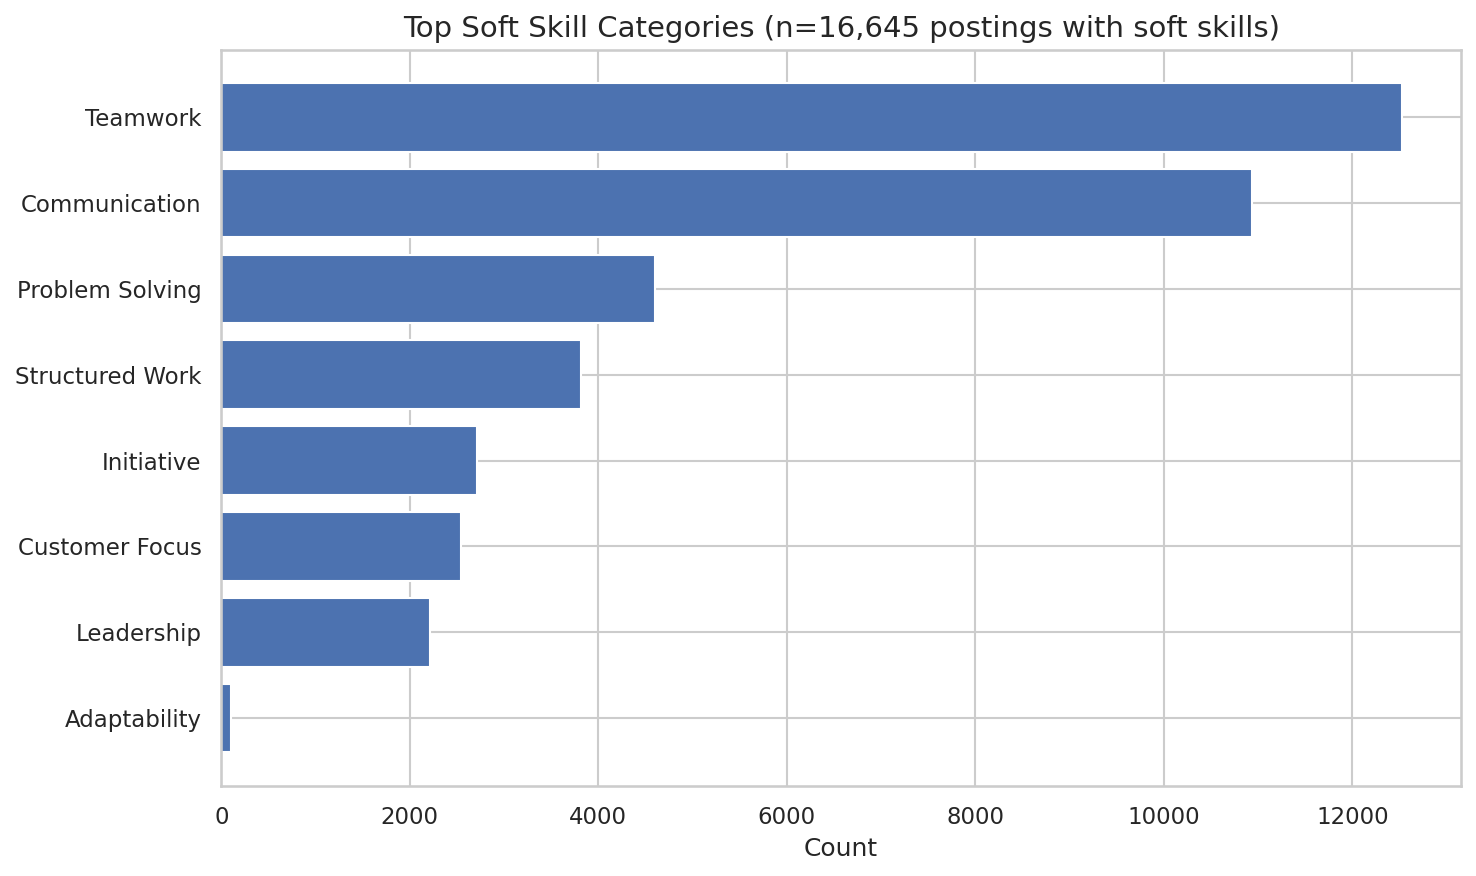

In [8]:
ss_exploded = explode_json_col(df, "soft_skill_categories")
n_with_ss = df["soft_skill_categories"].apply(lambda v: bool(parse_json_list(v))).sum()

horizontal_bar(
    ss_exploded["soft_skill_categories"],
    f"Top Soft Skill Categories (n={n_with_ss:,} postings with soft skills)",
    top_n=20,
    save_as="11_top_soft_skills.png",
)

**Takeaway:** The ranking of soft skills reflects what German IT employers most commonly request. Communication and teamwork dominate, consistent with the collaborative nature of modern software development. Problem-solving and analytical skills round out the top tier, while domain-specific soft skills (creativity, customer orientation) appear further down.

## Soft Skills by Seniority

Sample sizes per seniority level:
  Junior: n=736
  Mid: n=13,050
  Senior: n=4,162
  Lead: n=884



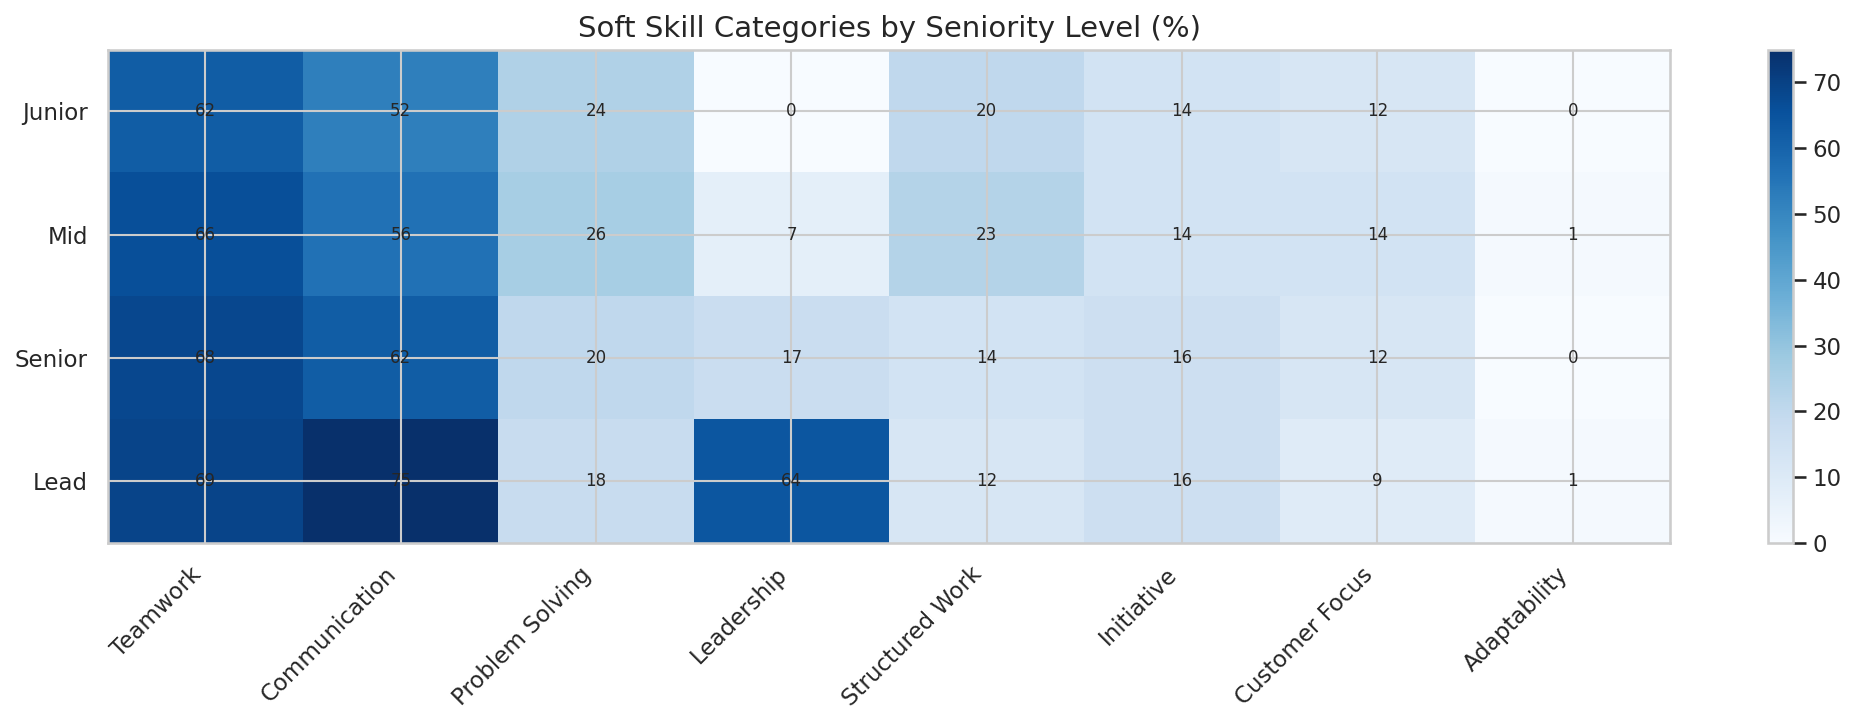

In [9]:
levels = ["Junior", "Mid", "Senior", "Lead"]
df_ss = df.copy()
df_ss["_level"] = df_ss["seniority_from_title"].fillna("Mid")
df_ss = df_ss[df_ss["_level"].isin(levels)]
df_ss["_cats"] = df_ss["soft_skill_categories"].apply(parse_json_list)

# Find all categories
all_cats = set()
for cats in df_ss["_cats"]:
    all_cats.update(c for c in cats if c)
all_cats = sorted(all_cats)

ss_sen_rows = []
for level in levels:
    level_df = df_ss[df_ss["_level"] == level]
    total = max(1, len(level_df))
    row = {"seniority": level}
    for cat in all_cats:
        row[cat] = level_df["_cats"].apply(lambda lst, c=cat: c in lst).sum() / total * 100
    ss_sen_rows.append(row)

ss_sen_df = pd.DataFrame(ss_sen_rows).set_index("seniority")
# Sort columns by overall prevalence
col_order = ss_sen_df.mean().sort_values(ascending=False).index
ss_sen_df = ss_sen_df[col_order]

# Show sample sizes
print("Sample sizes per seniority level:")
for level in levels:
    n = len(df_ss[df_ss["_level"] == level])
    print(f"  {level}: n={n:,}")
print()

heatmap(
    ss_sen_df.round(0),
    "Soft Skill Categories by Seniority Level (%)",
    figsize=(14, 5),
    fmt=".0f",
    save_as="11_soft_skills_by_seniority.png",
)

**Takeaway:** Soft skill expectations escalate with seniority. Leadership and strategic thinking become significantly more prominent at Senior and Lead levels, while foundational skills like communication and teamwork remain important throughout. Junior roles place relatively more emphasis on learning ability and adaptability, reflecting the expectation that entry-level hires will grow into their positions.